Executing on device: cpu
Generating static test set for final evaluation...
Starting PI-STGNN training...
---------------------------------------------------------------------------
Epoch 015/150 | Total Loss: 1.0495 | Class Loss: 0.5727 | Phys Residual: 0.0338 | Training Acc: 65.62% | Attack F1: 59.26%
Epoch 030/150 | Total Loss: 0.8616 | Class Loss: 0.4075 | Phys Residual: 0.0410 | Training Acc: 71.88% | Attack F1: 70.97%
Epoch 045/150 | Total Loss: 1.1166 | Class Loss: 0.6698 | Phys Residual: 0.1063 | Training Acc: 68.75% | Attack F1: 72.22%
Epoch 060/150 | Total Loss: 0.7416 | Class Loss: 0.3525 | Phys Residual: 0.2483 | Training Acc: 93.75% | Attack F1: 92.31%
Epoch 075/150 | Total Loss: 1.0512 | Class Loss: 0.6885 | Phys Residual: 0.3853 | Training Acc: 68.75% | Attack F1: 61.54%
Epoch 090/150 | Total Loss: 0.6203 | Class Loss: 0.2758 | Phys Residual: 0.2844 | Training Acc: 90.62% | Attack F1: 89.66%
Epoch 105/150 | Total Loss: 0.7968 | Class Loss: 0.4621 | Phys Residual: 0.3734 

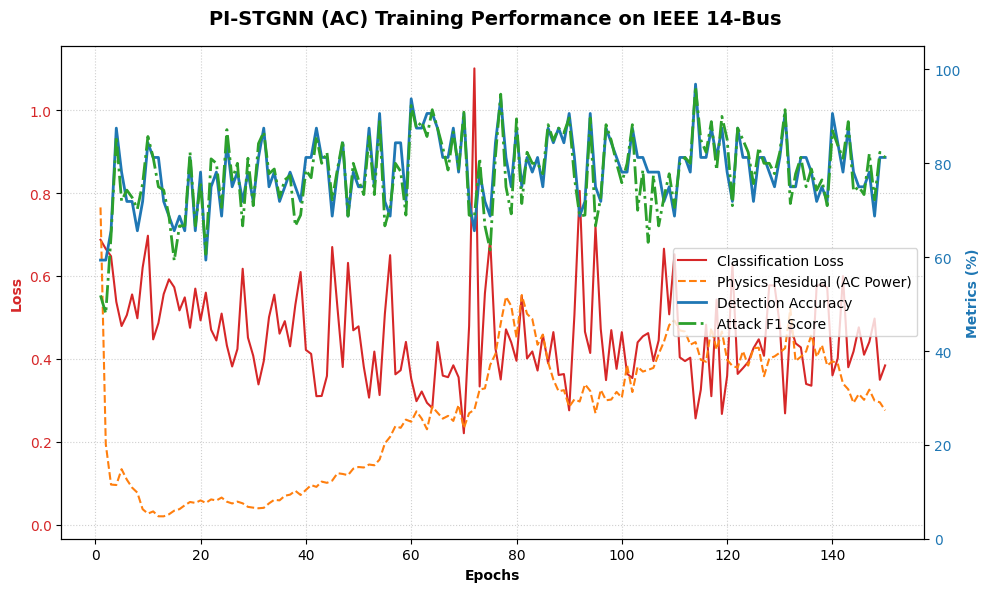

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# =====================================================================
# 1. TOPOLOGY & COMPLEX ADMITTANCE GENERATION (IEEE 14-BUS AC SYSTEM)
# =====================================================================
def build_ieee14_ybus():
    num_nodes = 14
    lines = [
        (0, 1, 0.01938, 0.05917), (0, 4, 0.05403, 0.22304), (1, 2, 0.04699, 0.19797),
        (1, 3, 0.05811, 0.17632), (1, 4, 0.05695, 0.17388), (2, 3, 0.06701, 0.17103),
        (3, 4, 0.01335, 0.04211), (3, 6, 0.00000, 0.20912), (3, 8, 0.00000, 0.55618),
        (4, 5, 0.00000, 0.25202), (5, 10, 0.09498, 0.19890), (5, 11, 0.12291, 0.25581),
        (5, 12, 0.06615, 0.13027), (6, 7, 0.00000, 0.17615), (6, 8, 0.00000, 0.11001),
        (8, 9, 0.03181, 0.08450), (8, 13, 0.12711, 0.27038), (9, 10, 0.08205, 0.19207),
        (11, 12, 0.22092, 0.19988), (12, 13, 0.17093, 0.34802)
    ]

    adj = torch.zeros((num_nodes, num_nodes))
    G = torch.zeros((num_nodes, num_nodes))
    B = torch.zeros((num_nodes, num_nodes))

    for u, v, r, x in lines:
        z_sq = r**2 + x**2
        g = r / z_sq
        b = -x / z_sq

        G[u, v], G[v, u] = -g, -g
        B[u, v], B[v, u] = -b, -b
        adj[u, v], adj[v, u] = 1.0, 1.0

    for i in range(num_nodes):
        adj[i, i] = 1.0
        G[i, i] = -torch.sum(G[i, :])
        B[i, i] = -torch.sum(B[i, :])

    return adj, G, B

# =====================================================================
# 2. SPATIO-TEMPORAL MULTI-HEAD GRAPH ATTENTION NETWORK (PI-STGNN)
# =====================================================================
class MultiHeadGATLayer(nn.Module):
    def __init__(self, in_features, out_features, num_heads=4, dropout=0.2, alpha=0.2):
        super(MultiHeadGATLayer, self).__init__()
        self.num_heads = num_heads
        self.out_features = out_features // num_heads

        self.W = nn.Parameter(torch.empty(size=(num_heads, in_features, self.out_features)))
        self.a_src = nn.Parameter(torch.empty(size=(num_heads, self.out_features, 1)))
        self.a_dst = nn.Parameter(torch.empty(size=(num_heads, self.out_features, 1)))

        nn.init.xavier_uniform_(self.W.data, gain=1.414)
        nn.init.xavier_uniform_(self.a_src.data, gain=1.414)
        nn.init.xavier_uniform_(self.a_dst.data, gain=1.414)

        self.leakyrelu = nn.LeakyReLU(alpha)
        self.dropout = dropout

    def forward(self, h, adj):
        B_batch, N, _ = h.size()
        Wh = torch.einsum('bni,hio->bhno', h, self.W)

        f_src = torch.einsum('bhno,hoi->bhn', Wh, self.a_src)
        f_dst = torch.einsum('bhno,hoi->bhn', Wh, self.a_dst)
        e = self.leakyrelu(f_src.unsqueeze(-1) + f_dst.unsqueeze(-2))

        zero_vec = -9e15 * torch.ones_like(e)
        adj_expanded = adj.unsqueeze(0).unsqueeze(0).expand_as(e)
        attention = torch.where(adj_expanded > 0, e, zero_vec)
        attention = F.softmax(attention, dim=-1)
        attention = F.dropout(attention, self.dropout, training=self.training)

        h_prime = torch.matmul(attention, Wh)
        h_prime = h_prime.permute(0, 2, 1, 3).contiguous().view(B_batch, N, -1)
        return F.elu(h_prime)

class SpatioTemporalBlock(nn.Module):
    def __init__(self, in_channels, spatial_channels, out_channels):
        super(SpatioTemporalBlock, self).__init__()
        self.temporal_conv1 = nn.Conv2d(in_channels, spatial_channels, kernel_size=(3, 1), padding=(1, 0))
        self.temporal_gate1 = nn.Conv2d(in_channels, spatial_channels, kernel_size=(3, 1), padding=(1, 0))
        self.spatial_gat = MultiHeadGATLayer(spatial_channels, spatial_channels, num_heads=4)
        self.temporal_conv2 = nn.Conv2d(spatial_channels, out_channels, kernel_size=(3, 1), padding=(1, 0))
        self.batch_norm = nn.BatchNorm2d(out_channels)

    def forward(self, x, adj):
        P = self.temporal_conv1(x)
        Q = torch.sigmoid(self.temporal_gate1(x))
        t_out = P * Q

        B_batch, C, T, N = t_out.size()
        t_out_swapped = t_out.permute(0, 2, 3, 1).contiguous().view(B_batch * T, N, C)
        s_out = self.spatial_gat(t_out_swapped, adj)
        s_out = s_out.view(B_batch, T, N, C).permute(0, 3, 1, 2).contiguous()

        out = self.temporal_conv2(F.relu(s_out))
        return self.batch_norm(out)

class PISTGNN(nn.Module):
    def __init__(self, num_nodes=14, in_features=4, hidden_dim=32, num_classes=2):
        super(PISTGNN, self).__init__()
        self.st_block1 = SpatioTemporalBlock(in_features, hidden_dim, hidden_dim)
        self.st_block2 = SpatioTemporalBlock(hidden_dim, hidden_dim, hidden_dim)

        self.grid_classifier = nn.Sequential(
            nn.Linear(hidden_dim * num_nodes, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

        self.state_reconstructor = nn.Linear(hidden_dim, in_features)

    def forward(self, x, adj):
        x_in = x.permute(0, 3, 1, 2).contiguous()
        h1 = self.st_block1(x_in, adj)
        h2 = self.st_block2(h1, adj)

        h_pool = torch.mean(h2, dim=2)
        h_nodes = h_pool.permute(0, 2, 1).contiguous()

        grid_logits = self.grid_classifier(h_nodes.view(h_nodes.size(0), -1))
        recon_state = self.state_reconstructor(h_nodes)

        return grid_logits, recon_state

# =====================================================================
# 3. NON-LINEAR AC POWER FLOW PHYSICS-CONSISTENCY LOSS
# =====================================================================
class ACPhysicsConsistencyLoss(nn.Module):
    def __init__(self, G_matrix, B_matrix):
        super(ACPhysicsConsistencyLoss, self).__init__()
        self.register_buffer('G', G_matrix)
        self.register_buffer('B', B_matrix)

    def forward(self, measurements):
        P_meas = measurements[:, :, 0]
        Q_meas = measurements[:, :, 1]
        V_mag  = measurements[:, :, 2]
        theta  = measurements[:, :, 3]

        theta_diff = theta.unsqueeze(2) - theta.unsqueeze(1)
        cos_diff, sin_diff = torch.cos(theta_diff), torch.sin(theta_diff)

        term_P = self.G * cos_diff + self.B * sin_diff
        P_calc = V_mag * torch.matmul(term_P, V_mag.unsqueeze(-1)).squeeze(-1)

        term_Q = self.G * sin_diff - self.B * cos_diff
        Q_calc = V_mag * torch.matmul(term_Q, V_mag.unsqueeze(-1)).squeeze(-1)

        return F.mse_loss(P_calc, P_meas) + F.mse_loss(Q_calc, Q_meas)

# =====================================================================
# 4. TRAINING, EVALUATION & PLOTTING PIPELINE
# =====================================================================
def run_and_evaluate(epochs=150, batch_size=32, seq_len=12, lambda_phys=0.05):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Executing on device: {device}")

    adj, G, B = build_ieee14_ybus()
    adj, G, B = adj.to(device), G.to(device), B.to(device)

    model = PISTGNN(num_nodes=14, in_features=4, hidden_dim=32, num_classes=2).to(device)
    phys_criterion = ACPhysicsConsistencyLoss(G, B)
    class_criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)

    history = {'total_loss': [], 'class_loss': [], 'phys_loss': [], 'accuracy': [], 'recall': [], 'f1': []}

    print("Generating static test set for final evaluation...")
    torch.manual_seed(999)
    test_batch_size = 100
    test_telemetry = torch.randn(test_batch_size, seq_len, 14, 4).to(device)
    test_telemetry[:, :, :, 2] = 1.0 + 0.02 * test_telemetry[:, :, :, 2]
    test_labels = torch.randint(0, 2, (test_batch_size,)).to(device)

    for b in range(test_batch_size):
        if test_labels[b] == 1:
            test_telemetry[b, :, 3:6, 0] += 0.8 * torch.rand(seq_len, 3).to(device)

    print("Starting PI-STGNN training...\n" + "-" * 75)
    for epoch in range(epochs):
        model.train()

        telemetry = torch.randn(batch_size, seq_len, 14, 4).to(device)
        telemetry[:, :, :, 2] = 1.0 + 0.02 * telemetry[:, :, :, 2]
        labels = torch.randint(0, 2, (batch_size,)).to(device)

        for b in range(batch_size):
            if labels[b] == 1:
                telemetry[b, :, 3:6, 0] += 0.8 * torch.rand(seq_len, 3).to(device)

        optimizer.zero_grad()
        grid_logits, recon_state = model(telemetry, adj)

        loss_class = class_criterion(grid_logits, labels)
        loss_recon = F.mse_loss(recon_state, telemetry[:, -1, :, :])
        loss_phys = phys_criterion(recon_state)

        total_loss = loss_class + (0.5 * loss_recon) + (lambda_phys * loss_phys)
        total_loss.backward()
        optimizer.step()

        preds = grid_logits.argmax(dim=-1)
        acc = (preds == labels).float().mean().item()

        tp = ((preds == 1) & (labels == 1)).float().sum().item()
        fp = ((preds == 1) & (labels == 0)).float().sum().item()
        fn = ((preds == 0) & (labels == 1)).float().sum().item()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        history['total_loss'].append(total_loss.item())
        history['class_loss'].append(loss_class.item())
        history['phys_loss'].append(loss_phys.item())
        history['accuracy'].append(acc * 100)
        history['recall'].append(recall * 100)
        history['f1'].append(f1 * 100)

        if (epoch + 1) % 15 == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | Total Loss: {total_loss.item():.4f} | "
                  f"Class Loss: {loss_class.item():.4f} | Phys Residual: {loss_phys.item():.4f} | "
                  f"Training Acc: {acc * 100:.2f}% | Attack F1: {f1 * 100:.2f}%")

    print("-" * 75)
    print("Optimization Complete.")

    print("\n" + "=" * 75)
    print("INITIATING FINAL EVALUATION ON UNSEEN TEST SET...")
    model.eval()
    with torch.no_grad():
        test_logits, test_recon = model(test_telemetry, adj)

        test_loss_class = class_criterion(test_logits, test_labels)
        test_loss_phys = phys_criterion(test_recon)

        test_preds = test_logits.argmax(dim=-1)
        test_acc = (test_preds == test_labels).float().mean().item()

    print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
    print(f"Test Classification Loss: {test_loss_class.item():.4f}")
    print(f"Test Physics Residual: {test_loss_phys.item():.4f}\n")

    labels_cpu = test_labels.cpu().numpy()
    preds_cpu = test_preds.cpu().numpy()

    print("FINAL CLASSIFICATION REPORT FOR FALSE DATA INJECTIONS:")
    print(classification_report(labels_cpu, preds_cpu, target_names=['Normal (0)', 'Attack (1)'], zero_division=0))
    print("=" * 75 + "\n")

    return history

def plot_training_results(history, filename="ac_performance_results.png"):
    epochs = range(1, len(history['accuracy']) + 1)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('Loss', color='tab:red', fontweight='bold')
    ax1.plot(epochs, history['class_loss'], color='tab:red', linestyle='-', label='Classification Loss')
    ax1.plot(epochs, history['phys_loss'], color='tab:orange', linestyle='--', label='Physics Residual (AC Power)')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.grid(True, linestyle=':', alpha=0.6)

    ax2 = ax1.twinx()
    ax2.set_ylabel('Metrics (%)', color='tab:blue', fontweight='bold')
    ax2.plot(epochs, history['accuracy'], color='tab:blue', linewidth=2, label='Detection Accuracy')
    ax2.plot(epochs, history['f1'], color='tab:green', linewidth=2, linestyle='-.', label='Attack F1 Score')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim([0, 105])

    fig.suptitle('PI-STGNN (AC) Training Performance on IEEE 14-Bus', fontsize=14, fontweight='bold')
    fig.tight_layout()

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

    plt.savefig(filename, dpi=300)
    print(f"\nSaved analysis visualization to {filename}")
    plt.show()

# Run the complete sequence
history = run_and_evaluate(epochs=150)
plot_training_results(history)